<a href="https://colab.research.google.com/github/Gerardocmdz/VERANO-PDI/blob/main/Actividad%204%20Transformadas%20geom%C3%A9tricas%20y%20de%20Fourier/ACT_4_PDI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Actividad 4: Transformadas geometricas de Fourier***

In [ ]:
#Cargamos el drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## ***Parte I. Preprocesamiento***

In [ ]:
import cv2
from google.colab.patches import cv2_imshow
import numpy as np
import matplotlib.pyplot as plt
directorio = '/content/drive/MyDrive/IMAGENES/colibri.jpg' #Direccion de la imagen
#Mostramos la imagen para ver si se cargo correctamente
img = cv2.imread(directorio)
cv2_imshow(img)

In [ ]:
#Convertimos la imagen a escala de grises
img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
cv2_imshow(img_gris)

## ***Aplicación de Transformaciones***

In [ ]:
#Traslacion
ancho, alto = img_gris.shape[:2] #Guardamos las dimensiones de la imagen
tx,ty = 80, 60

M = np.float32([
    [1,0,tx],
    [0,1,ty]
    ])
#Aplicamos el warp affine
wA = cv2.warpAffine(img_gris,M,(ancho,alto))
cv2_imshow(wA)

Dimensiones de la imagen original: (3000, 5353)
Dimensiones de la imagen redimensionada: (750, 1338)


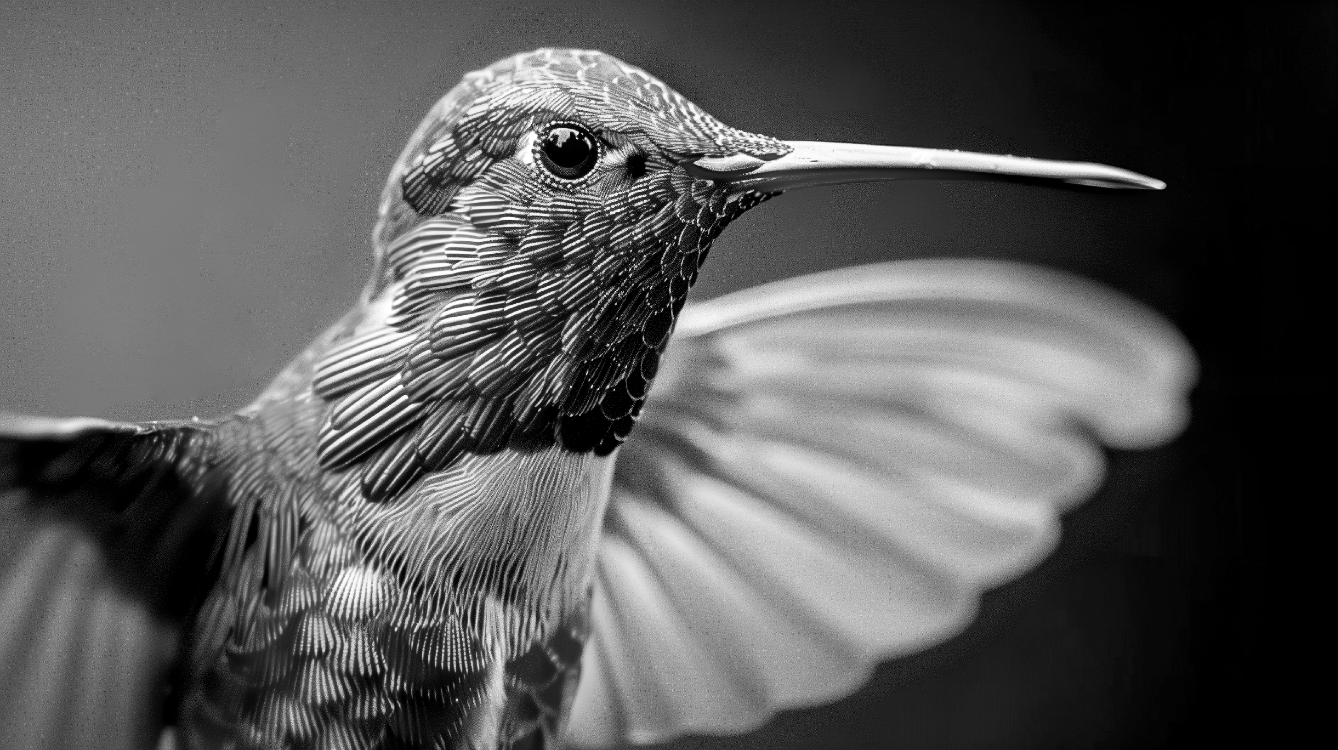

In [ ]:
#Aplicando resize

res = cv2.resize(img_gris,None,fx=0.25,fy=0.25)
an1,al1 = res.shape[:2]
print(f"Dimensiones de la imagen original: {ancho,alto}")
print(f"Dimensiones de la imagen redimensionada: {an1,al1}")
cv2_imshow(res)

In [ ]:
#ROTACION
# Centro de la imagen
centro = (ancho // 2, alto // 2)

# Parámetros de rotación
angulo = 60
escala = 1

# Matriz de rotación
M_rot = cv2.getRotationMatrix2D(centro, angulo, escala)

# Aplicar rotación
rot = cv2.warpAffine(img_gris, M_rot, (ancho, alto))

cv2_imshow(rot )

In [ ]:
#Reflexion
flip_hor = cv2.flip(img_gris, 1)
cv2_imshow(flip_hor)

## ***Parte II. Transformacion al dominio frecuencial***

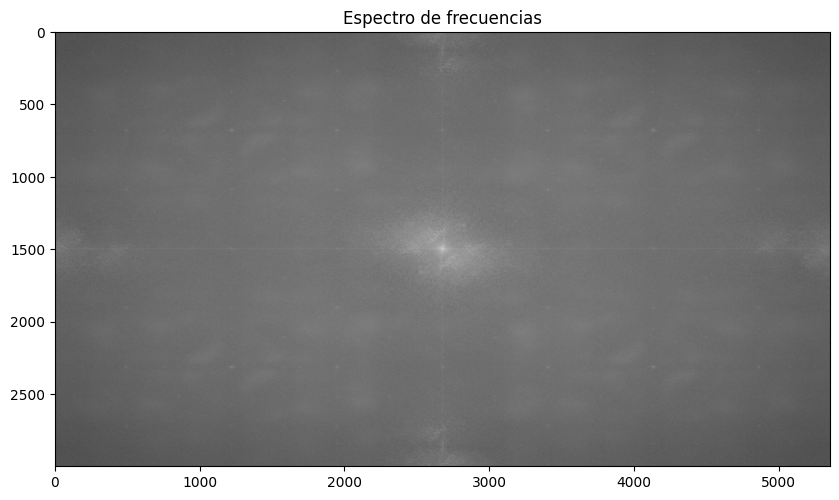

In [ ]:
dft = np.fft.fft2(img_gris)
dft_shift = np.fft.fftshift(dft)

magn = np.abs(dft_shift) #Magnitud
espectro = 20 * np.log(magn) #Espectro

plt.figure(figsize=(10, 6))
plt.imshow(espectro, cmap='gray')
plt.title("Espectro de frecuencias")
plt.show()